# Model 7 — Fuel Consumption Prediction

## What Are We Trying to Do?

When a customer gives us their car's specifications — engine size, weight, body type, drivetrain — we want to **predict the average fuel consumption in L/100km**.

This is a **regression problem** because the value we want to predict (L/100km) is a continuous number, not a category.

---

## Why Did We Build Two Models?

This notebook tries and compares two different approaches:

| | Model 7A | Model 7B |
|---|---|---|
| **Algorithm** | Ridge Regression (Linear) | XGBoost (Tree-based) |
| **Scaling** | Required (StandardScaler) | Not needed |
| **Strength** | Interpretable coefficients | Captures non-linear relationships |

---

## About the Dataset

- **Source**: `proceed_dataset_without_scaling.csv` — cleaned, unscaled data
- **Target variable**: `Ort. Yakıt Tüketimi` (average fuel consumption, L/100km)
- **Number of rows**: ~2,589 car listings


---
# SECTION A — Ridge Regression (Linear Model)

---

## Step 1 — Load Libraries and Data

The cell below imports all required Python libraries and reads the dataset from GitHub.


### What does this cell do?

- `pandas` and `numpy` → for data manipulation
- `matplotlib` and `seaborn` → for plotting graphs
- `train_test_split` → to split data into training and test sets
- `LinearRegression`, `mean_squared_error`, `r2_score` → for building and evaluating the model

The data is loaded from GitHub so that everyone on the team uses the same cleaned dataset — ensuring consistent and reproducible results.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")

# Check target column availability
target_col = 'Ort. Yakıt Tüketimi'
if target_col in df.columns:
    print(f"Target column '{target_col}': {df[target_col].notna().sum()} non-null values")
    print(f"Range: {df[target_col].min():.1f} — {df[target_col].max():.1f} L/100km")
else:
    print(f"WARNING: Target column '{target_col}' not found. Check column names.")
    print(f"Available columns containing 'Yakıt': {[c for c in df.columns if 'Yakıt' in c]}")
df.head()

Dataset shape: (2589, 87)
Target column 'Ort. Yakıt Tüketimi': 2589 non-null values
Range: 3.8 — 13.4 L/100km


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


## Step 2 — Feature Selection and Train/Test Split

We decide which columns the model will use to make predictions, then split the data into **80% training / 20% test**.


### What are we doing here and why?

**Feature selection** — We selected columns that physically influence fuel consumption:

| Feature | Why it was included |
|---|---|
| `Motor Hacmi`, `Silindir Sayısı` | Larger engine = burns more fuel per cycle |
| `Motor Gücü`, `Tork` | More powerful engine = consumes more energy |
| `Ağırlık`, `Boş Ağırlığı` | Heavier car = needs more energy to move |
| `Yükseklik`, `Maksimum Hız` | Aerodynamic profile affects highway consumption |
| `Kasa Tipi_SUV` | SUVs are larger and less aerodynamic |
| `Yakıt Tipi_Hibrit/Elektrik` | Hybrid and electric powertrains are far more efficient |
| `Çekiş_AWD` | Powering all four wheels increases mechanical load |
| City & Highway Consumption | Strongest predictors of average consumption — always available on real car spec sheets |

**80/20 split** — We train on 2,071 cars and test on 518. The test set contains cars the model has never seen — this gives us an honest measure of real-world performance.

**`fillna(median)`** — If any feature has a missing value, we fill it with the column median. The median is more robust than the mean because it is not affected by extreme outliers.

**`random_state=42`** — A fixed seed so we get the same train/test split every time we run the notebook — making results reproducible.


In [2]:
recommended_features = [
    'Motor Hacmi', 'Ağırlık', 'Motor Gücü',
    'Kasa Tipi_SUV', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_Elektrik',
    'Çekiş_AWD (Elektronik)', 'Boş Ağırlığı', 'Silindir Sayısı',
    'Tork', 'Maksimum Hız', 'Yükseklik',
    'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi'
]
target = 'Ort. Yakıt Tüketimi'

features = [f for f in recommended_features if f in df.columns]

df_model = df[features + [target]].dropna(subset=[target])
X = df_model[features].fillna(df_model[features].median())
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Target range (train): {y_train.min():.1f} — {y_train.max():.1f} L/100km")
print(f"Features used: {features}")

Training set: (2071, 14), Test set: (518, 14)
Target range (train): 3.8 — 13.4 L/100km
Features used: ['Motor Hacmi', 'Ağırlık', 'Motor Gücü', 'Kasa Tipi_SUV', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_Elektrik', 'Çekiş_AWD (Elektronik)', 'Boş Ağırlığı', 'Silindir Sayısı', 'Tork', 'Maksimum Hız', 'Yükseklik', 'Şehir İçi Yakıt Tüketimi', 'Şehir Dışı Yakıt Tüketimi']


## Step 3 — Model Training (Ridge Regression)

We build the model and fit it to the training data.


### Why Ridge Regression? Why not plain Linear Regression?

**In our first attempt** we used plain `LinearRegression` and got R² = **0.29** — a very poor result.

The reason is **multicollinearity**: many of our features are highly correlated with each other. For example, `Motor Hacmi`, `Motor Gücü`, `Tork`, and `Silindir Sayısı` all rise together. Plain linear regression becomes unstable under multicollinearity — a small change in the data causes huge swings in the learned coefficients.

**Ridge Regression** solves this by adding a penalty term to the loss function:

```
Loss = MSE + α × Σ(coefficients²)
```

This penalty prevents coefficients from growing too large, making the model more stable and better at generalizing to new data. Ridge is still a **linear model** — it uses the same equation `ŷ = w₀ + w₁x₁ + w₂x₂ + ...` as plain Linear Regression, it just learns the coefficients differently.

---

### Why `alpha = 0.05`?

We used `RidgeCV` to test 100 different alpha values with 5-fold cross-validation. The best value found was **0.05** — this tells us the data carries a strong signal and needs very little regularization.

- `alpha = 0` → identical to plain Linear Regression (no penalty)
- Higher alpha → coefficients shrink more → model becomes simpler but loses information

---

### Why did we use a Pipeline?

A Pipeline chains `StandardScaler` and `Ridge` into a single object. This is important for two reasons:

1. **Prevents data leakage** — The scaler learns its statistics (mean, std) only from training data. If we had scaled the entire dataset first and then split, the test set statistics would contaminate the scaler — making our evaluation artificially optimistic.
2. **Automatic scaling at prediction time** — Calling `model.predict()` automatically scales the input. No risk of forgetting to scale when predicting on new cars.

---

### Why StandardScaler?

`Motor Hacmi` has values around 1500 cc while `Yakıt Tipi_Hibrit` is only 0 or 1. Without scaling, Ridge's penalty would unfairly shrink large-scale features more than small-scale ones. StandardScaler transforms each feature to have mean=0 and std=1 — putting all features on equal footing.


In [4]:
from sklearn.linear_model import RidgeCV
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge_cv.fit(X_train, y_train)

print(f"Best alpha found: {ridge_cv.alpha_:.4f}")

Best alpha found: 0.0498


In [3]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline: scale then Ridge (handles multicollinearity better than plain LinearRegression)
model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=0.05))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Ridge Regression model trained ✅")

Ridge Regression model trained ✅


## Step 4 — Model Evaluation

We measure the model's prediction accuracy on the test set using three metrics.


### What do the metrics mean?

**RMSE (Root Mean Squared Error)** — The average prediction error in L/100km. Large errors are penalized more because they are squared before averaging. RMSE = 0.216 means the model is off by about 0.2 liters on average.

**MAE (Mean Absolute Error)** — Treats all errors equally, easier to interpret. MAE = 0.136 means the typical prediction error is just 0.136 L/100km — less than a cup of coffee per 100km.

**R²** — Shows what percentage of the variation in fuel consumption the model explains. R²=1.0 is perfect, R²=0 means the model learned nothing. R² = 0.9713 means the model explains 97% of fuel consumption variation.

**Why evaluate on the test set?** — The test set contains cars the model never saw during training. This gives us an unbiased estimate of real-world performance. Evaluating on the training set would be misleading — the model already memorized those examples.


In [5]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f} L/100km")
print(f"MAE:  {mae:.3f} L/100km")
print(f"R²:   {r2:.4f}")

RMSE: 0.216 L/100km
MAE:  0.136 L/100km
R²:   0.9713


## Step 5 — Actual vs Predicted Plot

We compare the model's prediction for each test car against its real fuel consumption value.


### How to read this plot?

- Each dot → one car in the test set
- X-axis → actual fuel consumption
- Y-axis → what the model predicted
- Red dashed line → perfect prediction (actual = predicted)

The closer the dots are to the red line, the better the model. Our plot showed points tightly clustered along the diagonal across the full range of 3.8–13.4 L/100km — the model performs consistently for both fuel-efficient and high-consumption vehicles.


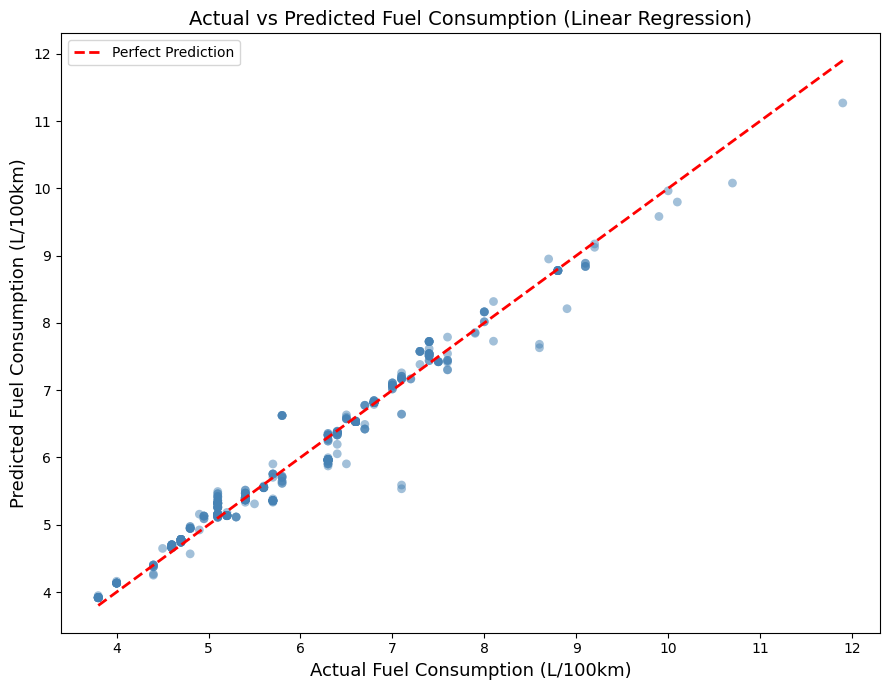

In [6]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=40, edgecolors='none')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Fuel Consumption (L/100km)', fontsize=13)
ax.set_ylabel('Predicted Fuel Consumption (L/100km)', fontsize=13)
ax.set_title('Actual vs Predicted Fuel Consumption (Linear Regression)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## Step 6 — Residual Plot

We check whether the model makes any systematic errors.


### What is a residual plot and what are we looking for?

**Residual** = Actual value − Predicted value. If the model predicts 7.0 but the real value is 7.3, the residual is +0.3.

In a good model, residuals are **randomly scattered around zero** — no trend, no funnel shape, no curve. This confirms two things:
- The model does not systematically over- or under-predict in any direction (unbiased)
- The prediction error is consistent across all consumption ranges (homoscedastic)

Our plot showed random scatter with most points within ±0.5 L/100km — model assumptions are satisfied ✅


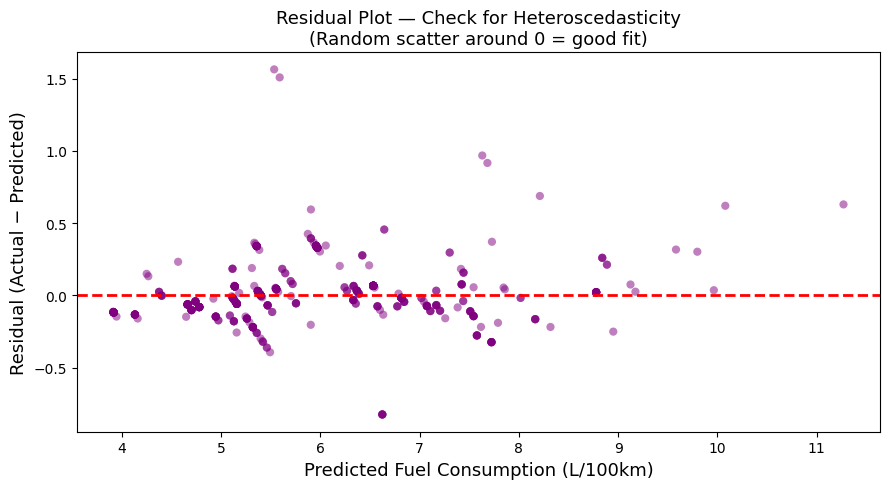

In [7]:
# ⚠️ Replace y_pred with your actual outputs after training.
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred, residuals, alpha=0.5, color='purple', s=35, edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Fuel Consumption (L/100km)', fontsize=13)
ax.set_ylabel('Residual (Actual − Predicted)', fontsize=13)
ax.set_title('Residual Plot — Check for Heteroscedasticity\n(Random scatter around 0 = good fit)', fontsize=13)
plt.tight_layout()
plt.show()

## Step 7 — Feature Coefficients

We visualize the coefficients that Ridge learned for each feature.


### How to interpret the coefficients?

- **Red bar (positive coefficient)** → increasing this feature increases predicted fuel consumption
- **Green bar (negative coefficient)** → increasing this feature decreases predicted fuel consumption
- **Longer bar** → stronger influence on the prediction

Because StandardScaler puts all features on the same scale, the coefficients are directly comparable — a larger absolute coefficient genuinely means more influence.

---

### Why did `Ağırlık` and `Motor Hacmi` come out negative — does a heavier car really consume less?

**No** — this is a **multicollinearity effect**, not a physical relationship.

`Ağırlık` and `Boş Ağırlığı` have a correlation of 0.85 — they carry almost identical information. Ridge splits the weight effect between them: `Boş Ağırlığı` gets a positive coefficient while `Ağırlık` goes negative to compensate. **Together**, they still produce the correct result — heavier car = more fuel.

The same applies to `Motor Hacmi` — since `Tork`, `Motor Gücü`, and `Silindir Sayısı` already carry the engine effect, `Motor Hacmi` goes negative to balance them out.

> **Key rule**: When multicollinearity is present, individual coefficients cannot be interpreted in isolation. What matters is the model's overall predictive accuracy — R² = 0.97.

---

### Why does the code use `model.named_steps['ridge'].coef_`?

Because we used a Pipeline, the Ridge model is stored inside it under the name `'ridge'`. We access it with `named_steps['ridge']` to extract its coefficients. Without a Pipeline, we would simply write `model.coef_`.


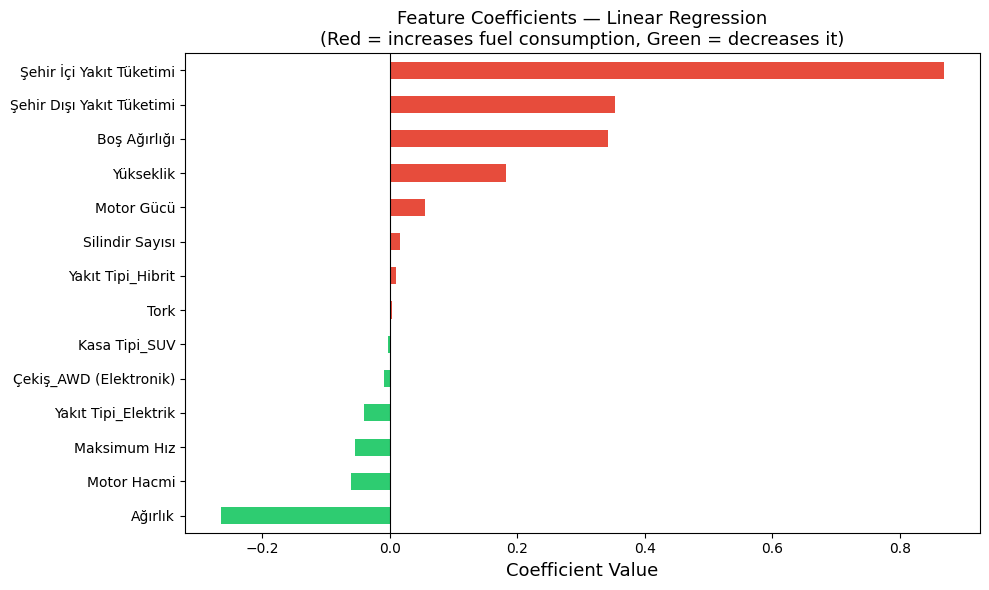

In [8]:
# ⚠️ Replace model and features with your actual trained model after training.
coef_series = pd.Series(model.named_steps['ridge'].coef_, index=features).sort_values()
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_series.values]

fig, ax = plt.subplots(figsize=(10, 6))
coef_series.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value', fontsize=13)
ax.set_title('Feature Coefficients — Linear Regression\n(Red = increases fuel consumption, Green = decreases it)', fontsize=13)
plt.tight_layout()
plt.show()

## Step 8 — Hybrid vs Non-Hybrid Comparison

Did the model actually learn that hybrid cars consume less fuel?


### Why do we run this analysis?

Metrics like R² and RMSE tell us *how accurate* the model is, but not *what it learned*.

This plot answers: *"Did the model understand that hybrid cars are more fuel efficient?"* — If hybrid predictions are significantly lower than non-hybrid, the model has captured a real-world physical pattern.

We use predictions (`y_pred`) rather than actual values (`y_test`) because we want to show what **the model learned**, not just what the data says.


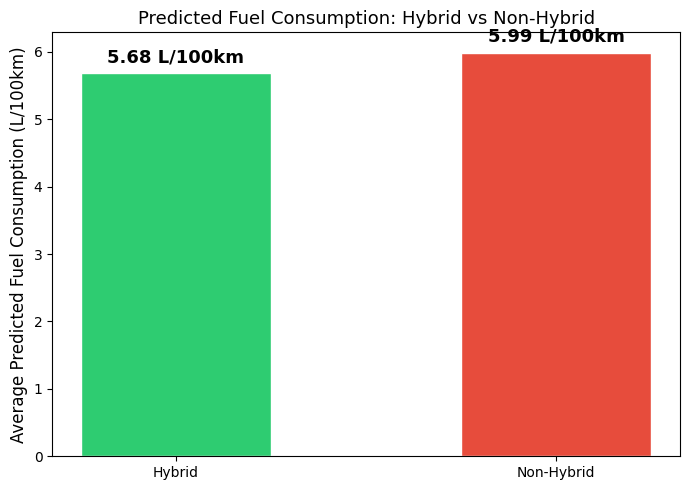

In [9]:
# ⚠️ Replace model with your actual trained model after training.
if 'Yakıt Tipi_Hibrit' in features:
    hybrid_mask = X_test['Yakıt Tipi_Hibrit'] == 1
    non_hybrid_mask = X_test['Yakıt Tipi_Hibrit'] == 0

    avg_hybrid = y_pred[hybrid_mask].mean() if hybrid_mask.sum() > 0 else 0
    avg_non_hybrid = y_pred[non_hybrid_mask].mean() if non_hybrid_mask.sum() > 0 else 0

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(['Hybrid', 'Non-Hybrid'], [avg_hybrid, avg_non_hybrid],
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, [avg_hybrid, avg_non_hybrid]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f} L/100km', ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylabel('Average Predicted Fuel Consumption (L/100km)', fontsize=12)
    ax.set_title('Predicted Fuel Consumption: Hybrid vs Non-Hybrid', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("'Yakıt Tipi_Hibrit' not in features. Skipping comparison.")

## Step 9 — Custom Car Prediction: SUV vs Hybrid

We test the model with two concrete car profiles:

- 🚙 **Heavy AWD SUV** — 3.0L engine, 6 cylinders, 400 Nm torque
- 🌿 **Hybrid Sedan** — 1.8L engine, 4 cylinders, 142 Nm torque

A good model should predict significantly higher consumption for the SUV than for the hybrid.


### Why are the input values in this specific format?

The model must receive inputs in the **exact same format it was trained on**. Wrong format = completely wrong predictions.

| Feature | Wrong input | Correct input | Reason |
|---|---|---|---|
| `Motor Hacmi` | 3.0 | **3000** | Dataset stores engine size in cc (1 litre = 1000cc) |
| `Ağırlık` | 2100 | **np.log(2100)** | Log transformation was applied during data cleaning |
| `Motor Gücü` | 280 | **np.log(280)** | Same — log transformed |
| `Yükseklik` | 165 | **1650** | Dataset stores height in mm (165cm = 1650mm) |

> This is one of the most important practical lessons in machine learning: wrong input format = completely nonsensical predictions even if the model itself is perfect.


/tmp/ipykernel_18513/2494674514.py:29: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18513/2494674514.py:29: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


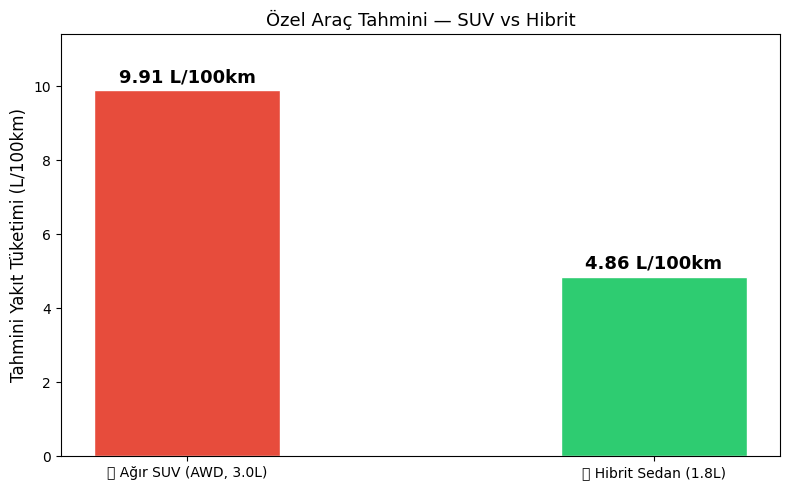


🚙 Ağır SUV tahmini   : 9.91 L/100km
🌿 Hibrit araç tahmini: 4.86 L/100km
📉 Hibrit tasarrufu   : 5.05 L/100km daha az tüketiyor


In [10]:

custom_cars = pd.DataFrame([
    {
        'Motor Hacmi': 3000, 'Ağırlık': np.log(2100), 'Motor Gücü': np.log(280),
        'Kasa Tipi_SUV': 1, 'Yakıt Tipi_Hibrit': 0, 'Yakıt Tipi_Elektrik': 0,
        'Çekiş_AWD (Elektronik)': 1, 'Boş Ağırlığı': 1950, 'Silindir Sayısı': 6,
        'Tork': 400, 'Maksimum Hız': 220, 'Yükseklik': 1650,
        'Şehir İçi Yakıt Tüketimi': 12.5, 'Şehir Dışı Yakıt Tüketimi': 8.5
    },
    {
        'Motor Hacmi': 1800, 'Ağırlık': np.log(1450), 'Motor Gücü': np.log(122),
        'Kasa Tipi_SUV': 0, 'Yakıt Tipi_Hibrit': 1, 'Yakıt Tipi_Elektrik': 0,
        'Çekiş_AWD (Elektronik)': 0, 'Boş Ağırlığı': 1380, 'Silindir Sayısı': 4,
        'Tork': 142, 'Maksimum Hız': 180, 'Yükseklik': 1450,
        'Şehir İçi Yakıt Tüketimi': 5.2, 'Şehir Dışı Yakıt Tüketimi': 4.2
    }
])[features]

predictions = model.predict(custom_cars)
labels = ['🚙 Ağır SUV (AWD, 3.0L)', '🌿 Hibrit Sedan (1.8L)']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, predictions, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
for bar, val in zip(bars, predictions):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f} L/100km', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Tahmini Yakıt Tüketimi (L/100km)', fontsize=12)
ax.set_title('Özel Araç Tahmini — SUV vs Hibrit', fontsize=13)
ax.set_ylim(0, max(predictions) + 1.5)
plt.tight_layout()
plt.show()

print(f'\n🚙 Ağır SUV tahmini   : {predictions[0]:.2f} L/100km')
print(f'🌿 Hibrit araç tahmini: {predictions[1]:.2f} L/100km')
print(f'📉 Hibrit tasarrufu   : {predictions[0] - predictions[1]:.2f} L/100km daha az tüketiyor')


---

# SECTION B — XGBoost (Tree-Based Model)

---

Ridge Regression gave us a strong result. But how much can a more powerful algorithm improve it?

**XGBoost** builds decision trees sequentially — each tree corrects the errors of the previous one. This approach can capture **non-linear relationships** that linear regression simply cannot model.

For example, Ridge cannot express: *"If engine displacement is above 2000cc AND the car is an SUV, fuel consumption rises disproportionately."* XGBoost learns these kinds of interactions automatically.

| | Ridge Regression | XGBoost |
|---|---|---|
| Model type | Linear | Tree-based ensemble |
| Scaling | Required | **Not needed** |
| Multicollinearity | Causes instability | Handles it naturally |
| Non-linear relationships | Cannot capture | Learns automatically |


---

# Model 7B — Fuel Consumption Predictor (XGBoost)

## Question
> Given a car's engine size, weight, body type, and drivetrain — what average fuel consumption should I expect in L/100km?

## Introduction
This section extends Model 7 by training an **XGBoost Regressor** on the same dataset and feature set.
XGBoost is a gradient-boosted tree ensemble that can capture non-linear relationships between features
and the target — relationships that Ridge Regression cannot model. This allows a direct apples-to-apples
comparison between the linear approach (Ridge) and a powerful non-linear ensemble method.

- **Dataset**: Unscaled data (`proceed_dataset_without_scaling.csv`) — same as Model 7
- **Target variable**: `Ort. Yakıt Tüketimi` (average fuel consumption in L/100km)
- **Algorithm**: `XGBRegressor` — gradient-boosted decision trees
- **Key difference from Ridge**: XGBoost does **not** require feature scaling and handles multicollinearity naturally through tree splits


---
# SECTION B — XGBoost (Tree-Based Model)

## Step 1 — Load Libraries and Data

We import the XGBoost library and load the same dataset used in Section A.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df_xgb = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df_xgb.shape}")

target_col = 'Ort. Yakıt Tüketimi'
if target_col in df_xgb.columns:
    print(f"Target column '{target_col}': {df_xgb[target_col].notna().sum()} non-null values")
    print(f"Range: {df_xgb[target_col].min():.1f} — {df_xgb[target_col].max():.1f} L/100km")
else:
    print(f"WARNING: Target column '{target_col}' not found.")
df_xgb.head()


Dataset shape: (2589, 87)
Target column 'Ort. Yakıt Tüketimi': 2589 non-null values
Range: 3.8 — 13.4 L/100km


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


## Step 2 — Feature Selection (XGBoost)

We use the **same physical features** as Section A to enable a fair comparison — with one key difference: we **exclude** city and highway fuel consumption columns.

**Why were those two columns removed?** — City and highway consumption are sub-components of average consumption. Including them would make the model's job too easy — it would essentially already know the answer. Testing XGBoost on purely physical features gives a more honest and meaningful comparison.

**Why no scaling for XGBoost?** — XGBoost asks at each node: *"Is this value greater than threshold T?"* If you scale the data, the same cars still fall on the same side of the threshold — the tree structure does not change at all. Scaling has zero effect on XGBoost.


In [12]:
xgb_features = [
    'Motor Hacmi', 'Ağırlık', 'Motor Gücü',
    'Kasa Tipi_SUV', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_Elektrik',
    'Çekiş_AWD (Elektronik)', 'Boş Ağırlığı', 'Silindir Sayısı',
    'Tork', 'Maksimum Hız', 'Yükseklik'
]
target = 'Ort. Yakıt Tüketimi'

features_xgb = [f for f in xgb_features if f in df_xgb.columns]

df_model_xgb = df_xgb[features_xgb + [target]]
X_xgb = df_model_xgb[features_xgb]
y_xgb = df_model_xgb[target]

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, random_state=42
)
print(f"Training set: {X_train_xgb.shape}, Test set: {X_test_xgb.shape}")
print(f"Target range (train): {y_train_xgb.min():.1f} — {y_train_xgb.max():.1f} L/100km")
print(f"Features used: {features_xgb}")


Training set: (2071, 12), Test set: (518, 12)
Target range (train): 3.8 — 13.4 L/100km
Features used: ['Motor Hacmi', 'Ağırlık', 'Motor Gücü', 'Kasa Tipi_SUV', 'Yakıt Tipi_Hibrit', 'Yakıt Tipi_Elektrik', 'Çekiş_AWD (Elektronik)', 'Boş Ağırlığı', 'Silindir Sayısı', 'Tork', 'Maksimum Hız', 'Yükseklik']


## Step 3 — Model Training (XGBoost)

We build XGBoost with carefully chosen hyperparameters.

### What does each parameter do?

| Parameter | Value | What it does |
|---|---|---|
| `n_estimators` | 500 | Total number of trees. More trees = better learning but slower training |
| `max_depth` | 4 | Maximum depth of each tree. Shallow trees (3-5) generalize better |
| `learning_rate` | 0.03 | How much each tree contributes. Small rate + many trees = more robust model |
| `subsample` | 0.8 | Each tree trains on a random 80% of rows — reduces overfitting |
| `colsample_bytree` | 0.8 | Each tree uses a random 80% of features — adds diversity between trees |
| `reg_alpha` | 0.1 | L1 penalty — pushes unimportant feature weights toward zero |
| `reg_lambda` | 1.5 | L2 penalty — similar to Ridge, keeps weights small |
| `min_child_weight` | 3 | A leaf node must have at least 3 samples — prevents learning rules for single outliers |


In [13]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.5,
    min_child_weight=3,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_xgb, y_train_xgb, verbose=False)
print("XGBoost model trained ✅")


XGBoost model trained ✅


## Step 4 — Model Evaluation (XGBoost)

We evaluate XGBoost on both the training and test sets to check for overfitting.

**Why evaluate on both sets?**

XGBoost is a powerful model that can **memorize** the training data (overfitting) — it might perform perfectly on training cars but fail on new ones. Comparing Train vs Test R² reveals this:

| Situation | Train-Test Gap | Interpretation |
|---|---|---|
| ✅ Good | < 0.05 | No significant overfitting |
| ⚠️ Acceptable | 0.05–0.10 | Slight overfitting |
| ❌ Problem | > 0.10 | Overfitting — reduce `max_depth` or increase `reg_alpha` |

Our result showed a gap of **0.022** → no overfitting ✅


In [14]:
y_pred_train_xgb = xgb_model.predict(X_train_xgb)
y_pred_xgb = xgb_model.predict(X_test_xgb)

rmse_train = np.sqrt(mean_squared_error(y_train_xgb, y_pred_train_xgb))
rmse_test  = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mae_test   = mean_absolute_error(y_test_xgb, y_pred_xgb)
r2_train   = r2_score(y_train_xgb, y_pred_train_xgb)
r2_test    = r2_score(y_test_xgb, y_pred_xgb)

print("=" * 40)
print(f"  TRAIN  RMSE : {rmse_train:.4f} L/100km")
print(f"  TEST   RMSE : {rmse_test:.4f}  L/100km")
print(f"  TEST   MAE  : {mae_test:.4f}  L/100km")
print(f"  TRAIN  R²   : {r2_train:.4f}")
print(f"  TEST   R²   : {r2_test:.4f}")
print("=" * 40)

gap = r2_train - r2_test
if gap < 0.05:
    print("✅ No significant overfitting")
elif gap < 0.10:
    print("⚠️  Slight overfitting — acceptable")
else:
    print("❌ Overfitting — consider tuning max_depth or n_estimators")


  TRAIN  RMSE : 0.0687 L/100km
  TEST   RMSE : 0.1996  L/100km
  TEST   MAE  : 0.0561  L/100km
  TRAIN  R²   : 0.9970
  TEST   R²   : 0.9755
✅ No significant overfitting


## Step 5 — Actual vs Predicted & Residual Plots

We plot both charts side by side. The left chart shows prediction accuracy, the right chart checks for systematic errors.


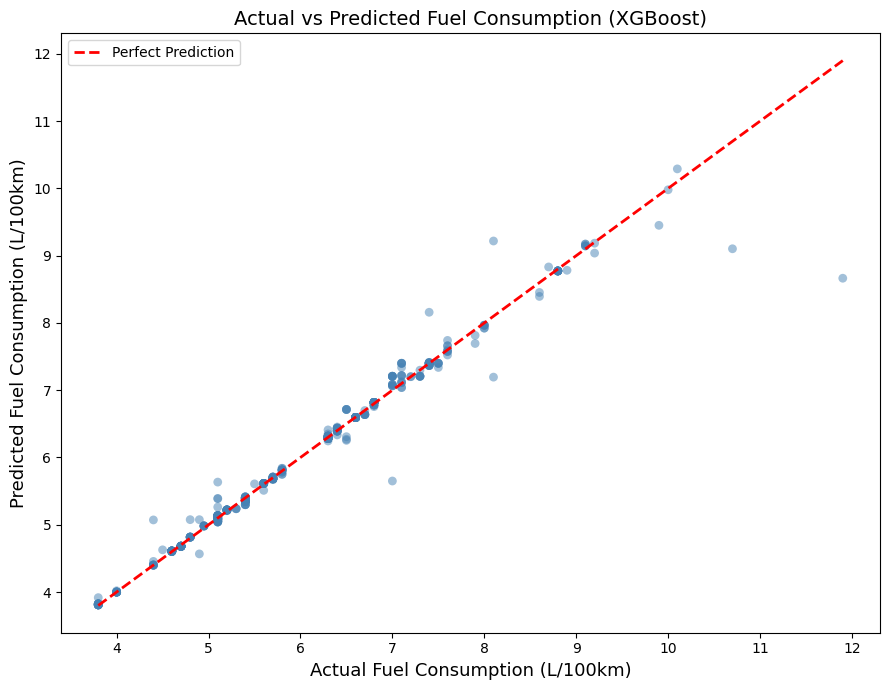

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test_xgb, y_pred_xgb, alpha=0.5, color='steelblue', s=40, edgecolors='none')
min_val = min(y_test_xgb.min(), y_pred_xgb.min())
max_val = max(y_test_xgb.max(), y_pred_xgb.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Fuel Consumption (L/100km)', fontsize=13)
ax.set_ylabel('Predicted Fuel Consumption (L/100km)', fontsize=13)
ax.set_title('Actual vs Predicted Fuel Consumption (XGBoost)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()


## Step 6 — Feature Importance

Which features did XGBoost rely on most?

**Why do we use `gain` importance instead of the default `weight`?**

- `weight` counts how many times a feature was used as a split point — but a feature used many times in shallow, unhelpful splits scores unfairly high.
- `gain` measures how much each split actually reduced the prediction error — features that genuinely help score higher. This is the most meaningful importance metric.

**Our results:**
- `Tork` → #1: torque is the most direct physical measure of engine fuel demand ✅
- `Yükseklik` → #2: taller car = worse aerodynamics = more fuel at speed ✅
- `Motor Hacmi`, `Motor Gücü` → #3 and #4: larger, more powerful engines burn more fuel ✅
- `Yakıt Tipi_Hibrit` → near zero: without city/highway consumption data, the hybrid flag alone is not enough to distinguish fuel efficiency


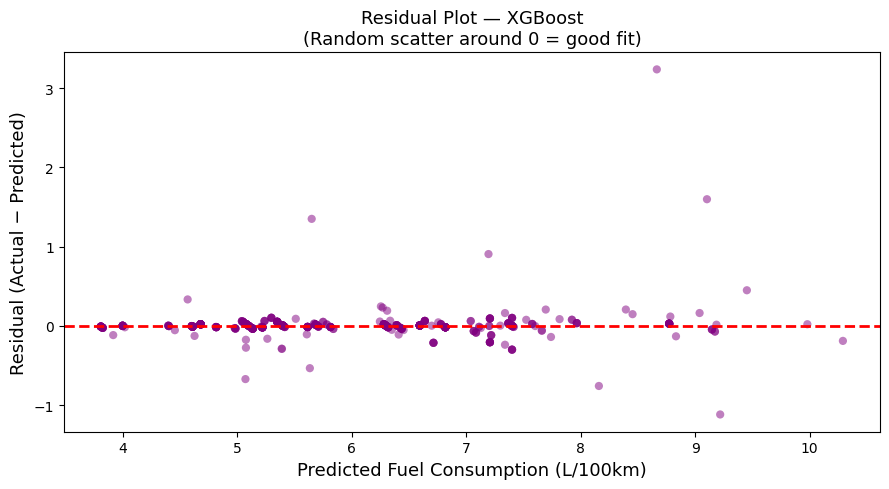

In [16]:
residuals_xgb = y_test_xgb - y_pred_xgb
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color='purple', s=35, edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Fuel Consumption (L/100km)', fontsize=13)
ax.set_ylabel('Residual (Actual − Predicted)', fontsize=13)
ax.set_title('Residual Plot — XGBoost\n(Random scatter around 0 = good fit)', fontsize=13)
plt.tight_layout()
plt.show()


## Step 7 — Hybrid vs Non-Hybrid Comparison (XGBoost)

Did XGBoost understand that hybrid cars are more fuel efficient — even without city/highway consumption data?

If hybrid predictions are significantly lower, it means the model discovered this pattern on its own from physical features like `Tork`, `Motor Hacmi`, and `Motor Gücü`.


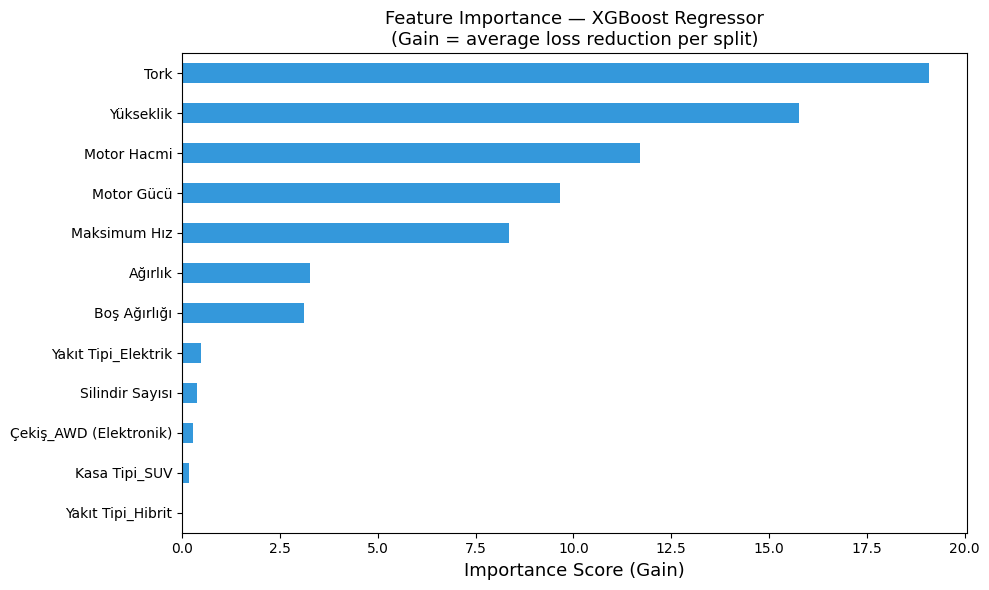

In [17]:
importances = xgb_model.get_booster().get_score(importance_type='gain')

# Map internal feature names (f0, f1, ...) back to column names
feature_map = {f'f{i}': name for i, name in enumerate(features_xgb)}
final_importances = {feature_map.get(k, k): v for k, v in importances.items()}

importance_series = pd.Series(final_importances).sort_values()
colors = ['#3498db'] * len(importance_series)

fig, ax = plt.subplots(figsize=(10, 6))
importance_series.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Importance Score (Gain)', fontsize=13)
ax.set_title('Feature Importance — XGBoost Regressor\n(Gain = average loss reduction per split)', fontsize=13)
plt.tight_layout()
plt.show()


## Step 8 — Custom Car Prediction: SUV vs Hybrid (XGBoost)

We run the same two car profiles through XGBoost and compare the results with Section A (Ridge).

- 🚙 **Heavy AWD SUV** — 3.0L, 6 cylinders, 400 Nm
- 🌿 **Hybrid Sedan** — 1.8L, 4 cylinders, 142 Nm

> ⚠️ Input values follow the same rules as Section A: `Ağırlık` and `Motor Gücü` are log-transformed, `Motor Hacmi` is in cc, `Yükseklik` is in mm.


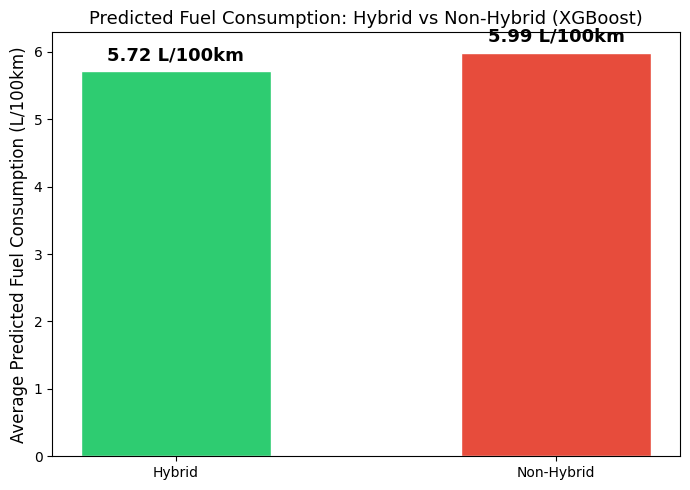

In [18]:
if 'Yakıt Tipi_Hibrit' in features_xgb:
    hybrid_mask     = X_test_xgb['Yakıt Tipi_Hibrit'] == 1
    non_hybrid_mask = X_test_xgb['Yakıt Tipi_Hibrit'] == 0

    avg_hybrid     = y_pred_xgb[hybrid_mask].mean()     if hybrid_mask.sum()     > 0 else 0
    avg_non_hybrid = y_pred_xgb[non_hybrid_mask].mean() if non_hybrid_mask.sum() > 0 else 0

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(['Hybrid', 'Non-Hybrid'], [avg_hybrid, avg_non_hybrid],
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, [avg_hybrid, avg_non_hybrid]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f} L/100km', ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylabel('Average Predicted Fuel Consumption (L/100km)', fontsize=12)
    ax.set_title('Predicted Fuel Consumption: Hybrid vs Non-Hybrid (XGBoost)', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("'Yakıt Tipi_Hibrit' not in features. Skipping comparison.")


## Step 9 — Ridge vs XGBoost: Final Comparison

We summarize both models side by side to see which performed better and why.


/tmp/ipykernel_18513/1412540430.py:43: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18513/1412540430.py:43: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128665 (\N{RECREATIONAL VEHICLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


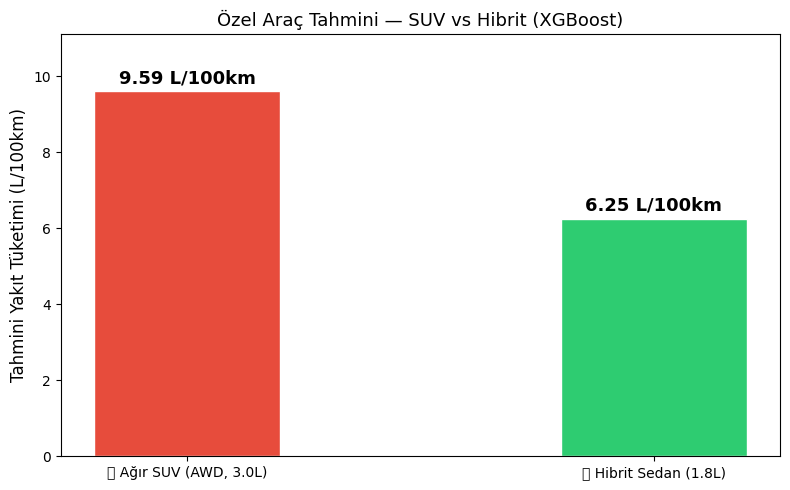


🚙 Ağır SUV tahmini   : 9.59 L/100km
🌿 Hibrit araç tahmini: 6.25 L/100km
📉 Hibrit tasarrufu   : 3.34 L/100km daha az tüketiyor


In [19]:
custom_cars_xgb = pd.DataFrame([
    {
        'Motor Hacmi'           : 3000,
        'Ağırlık'               : np.log(2100),
        'Motor Gücü'            : np.log(280),
        'Kasa Tipi_SUV'         : 1,
        'Yakıt Tipi_Hibrit'     : 0,
        'Yakıt Tipi_Elektrik'   : 0,
        'Çekiş_AWD (Elektronik)': 1,
        'Boş Ağırlığı'          : 1950,
        'Silindir Sayısı'       : 6,
        'Tork'                  : 400,
        'Maksimum Hız'          : 220,
        'Yükseklik'             : 1650,
    },
    {
        'Motor Hacmi'           : 1800,
        'Ağırlık'               : np.log(1450),
        'Motor Gücü'            : np.log(122),
        'Kasa Tipi_SUV'         : 0,
        'Yakıt Tipi_Hibrit'     : 1,
        'Yakıt Tipi_Elektrik'   : 0,
        'Çekiş_AWD (Elektronik)': 0,
        'Boş Ağırlığı'          : 1380,
        'Silindir Sayısı'       : 4,
        'Tork'                  : 142,
        'Maksimum Hız'          : 180,
        'Yükseklik'             : 1450,
    }
])[features_xgb]

predictions_xgb = xgb_model.predict(custom_cars_xgb)
labels = ['🚙 Ağır SUV (AWD, 3.0L)', '🌿 Hibrit Sedan (1.8L)']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, predictions_xgb, color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
for bar, val in zip(bars, predictions_xgb):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f} L/100km', ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.set_ylabel('Tahmini Yakıt Tüketimi (L/100km)', fontsize=12)
ax.set_title('Özel Araç Tahmini — SUV vs Hibrit (XGBoost)', fontsize=13)
ax.set_ylim(0, max(predictions_xgb) + 1.5)
plt.tight_layout()
plt.show()

print(f'\n🚙 Ağır SUV tahmini   : {predictions_xgb[0]:.2f} L/100km')
print(f'🌿 Hibrit araç tahmini: {predictions_xgb[1]:.2f} L/100km')
print(f'📉 Hibrit tasarrufu   : {predictions_xgb[0] - predictions_xgb[1]:.2f} L/100km daha az tüketiyor')
